# hplc-py

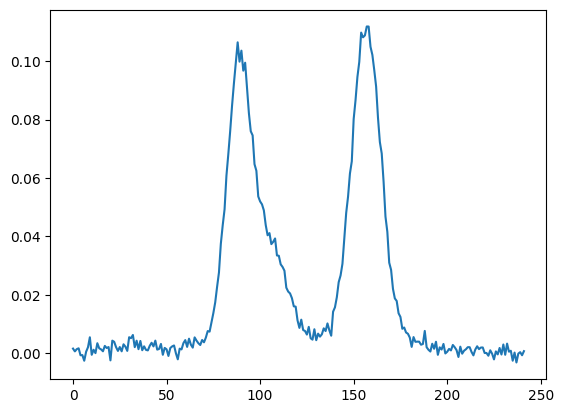

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from molass_data import SAMPLE1
from molass.DataObjects import SecSaxsData as SSD
ssd = SSD(SAMPLE1)
x, y = ssd.xr.get_icurve().get_xy()
fig, ax = plt.subplots()
ax.plot(x, y)
plt.show()

In [2]:
csv_path = "hplc-py-example.csv"
np.savetxt(csv_path, np.column_stack((x/20, y)), delimiter=",", header="time,signal", comments='')

[<Figure size 640x480 with 1 Axes>, <Axes: xlabel='time', ylabel='signal'>]

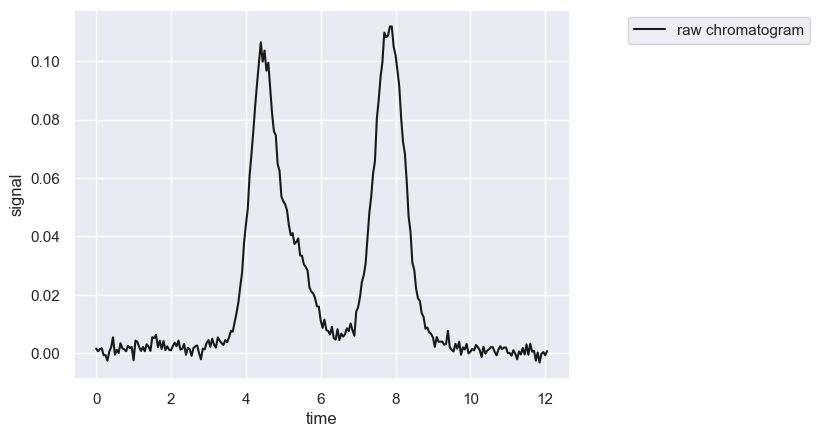

In [3]:
from hplc.io import load_chromatogram
from hplc.quant import Chromatogram
example = load_chromatogram(csv_path, cols=['time', 'signal'])
chrom = Chromatogram(example)
chrom.show()

In [4]:
peaks = chrom.fit_peaks(prominence=0.05)
peaks.head()

Performing baseline correction:   0%|          | 0/49 [00:00<?, ?it/s]

Performing baseline correction: 100%|██████████| 49/49 [00:00<00:00, 7525.76it/s]

Deconvolving mixture:   0%|          | 0/1 [00:00<?, ?it/s]

Deconvolving mixture: 100%|██████████| 1/1 [00:01<00:00,  1.72s/it]

Deconvolving mixture: 100%|██████████| 1/1 [00:01<00:00,  1.72s/it]

,retention_time,scale,skew,amplitude,area,signal_maximum,peak_id
0,0.4,0.011160,0.143289,0.001278,0.007779,0.005471,1
0,0.7,0.012835,0.413577,0.000458,0.004088,0.003025,2
0,0.8,2.944615,9.217561,0.012458,0.249099,0.003237,3
0,4.6,0.407060,-2.034294,0.067984,1.359681,0.099460,4
0,4.6,0.784367,5.773530,0.054106,1.082119,0.050649,5


[<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='time', ylabel='signal (baseline corrected)'>]

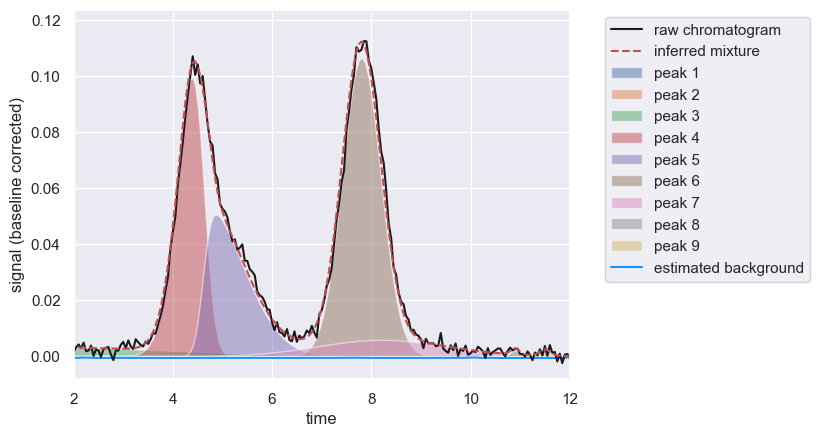

In [5]:
chrom.show([2, 12])